# Лабораторная работа 2

## Вычисление числа π методом Монте-Карло

**Последовательная версия**

In [4]:
import random
import math
import time
import concurrent.futures

def estimate_pi_sequential(n_points: int) -> float:
    """
    Вычисление числа π методом Монте-Карло.
    Бросаем случайные точки в квадрат [-1,1]x[-1,1],
    считаем, сколько попали в круг единичного радиуса.
    """
    inside = 0
    for _ in range(n_points):
        x = random.uniform(-1, 1)
        y = random.uniform(-1, 1)
        if x*x + y*y <= 1:
            inside += 1
    return 4 * inside / n_points

n_points = 100000
start_time = time.time()
pi_approx = estimate_pi_sequential(n_points)
print(f"π ≈ {pi_approx}")
print(f"Ошибка: {abs(pi_approx - math.pi):.6f}")
print(f"Время: {time.time() - start_time:.4f} сек")

π ≈ 3.14252
Ошибка: 0.000927
Время: 0.0667 сек


**Метод Монте-Карло с помощью потоков**

In [5]:
def estimate_pi_in_range(n_points: int) -> int:
    """Подсчёт точек, попавших в круг, для заданного количества итераций"""
    inside = 0
    for _ in range(n_points):
        x = random.uniform(-1, 1)
        y = random.uniform(-1, 1)
        if x*x + y*y <= 1:
            inside += 1
    return inside

def estimate_pi_threads(n_points: int, n_jobs: int = 4) -> float:
    """Вычисление π методом Монте-Карло с использованием потоков"""
    n_per_job = n_points // n_jobs

    with concurrent.futures.ThreadPoolExecutor(max_workers=n_jobs) as executor:
        futures = [executor.submit(estimate_pi_in_range, n_per_job) for _ in range(n_jobs)]
        results = [f.result() for f in futures]

    total_inside = sum(results)
    return 4 * total_inside / n_points

start_time = time.time()
pi_approx = estimate_pi_threads(n_points, n_jobs=4)
print(f"π ≈ {pi_approx}")
print(f"Время (потоки): {time.time() - start_time:.4f} сек")

π ≈ 3.13496
Время (потоки): 0.0626 сек


**Метод Монте-Карло с помощью процессов**

In [7]:
def estimate_pi_processes(n_points: int, n_jobs: int = 4) -> float:
    """Вычисление π методом Монте-Карло с использованием процессов"""
    n_per_job = n_points // n_jobs

    with concurrent.futures.ProcessPoolExecutor(max_workers=n_jobs) as executor:
        futures = [executor.submit(estimate_pi_in_range, n_per_job) for _ in range(n_jobs)]
        results = [f.result() for f in futures]

    total_inside = sum(results)
    return 4 * total_inside / n_points

start_time = time.time()
pi_approx = estimate_pi_processes(n_points, n_jobs=4)
print(f"π ≈ {pi_approx}")
print(f"Время (процессы): {time.time() - start_time:.4f} сек")

π ≈ 3.1424
Время (процессы): 0.1046 сек


**Сравнение производительности (метод Монте-Карло)**

In [8]:
def benchmark_pi():
    """Сравнение всех версий вычисления π методом Монте-Карло"""
    n_points = 500000
    n_jobs_list = [2, 4, 6, 8]

    print("Вычисление числа π методом Монте-Карло")
    print(f"Количество точек: {n_points}")


    start = time.time()
    pi_seq = estimate_pi_sequential(n_points)
    time_seq = time.time() - start
    print(f"\nПоследовательно:     {time_seq:.4f} сек (π ≈ {pi_seq:.6f})")

    print(f"\n{'n_jobs':<8} {'Потоки (сек)':<15} {'Процессы (сек)':<15} {'Ускорение (процессы)':<20}")
    print("-" * 70)

    for n_jobs in n_jobs_list:
        start = time.time()
        pi_thr = estimate_pi_threads(n_points, n_jobs)
        time_thr = time.time() - start
        start = time.time()
        pi_proc = estimate_pi_processes(n_points, n_jobs)
        time_proc = time.time() - start

        speedup = time_seq / time_proc

        print(f"{n_jobs:<8} {time_thr:<15.4f} {time_proc:<15.4f} {speedup:<20.2f}x")

benchmark_pi()

Вычисление числа π методом Монте-Карло
Количество точек: 500000

Последовательно:     0.3069 сек (π ≈ 3.139168)

n_jobs   Потоки (сек)    Процессы (сек)  Ускорение (процессы)
----------------------------------------------------------------------
2        0.2951          0.2977          1.03                x
4        0.3045          0.3112          0.99                x
6        0.2857          0.3208          0.96                x
8        0.3074          0.3448          0.89                x


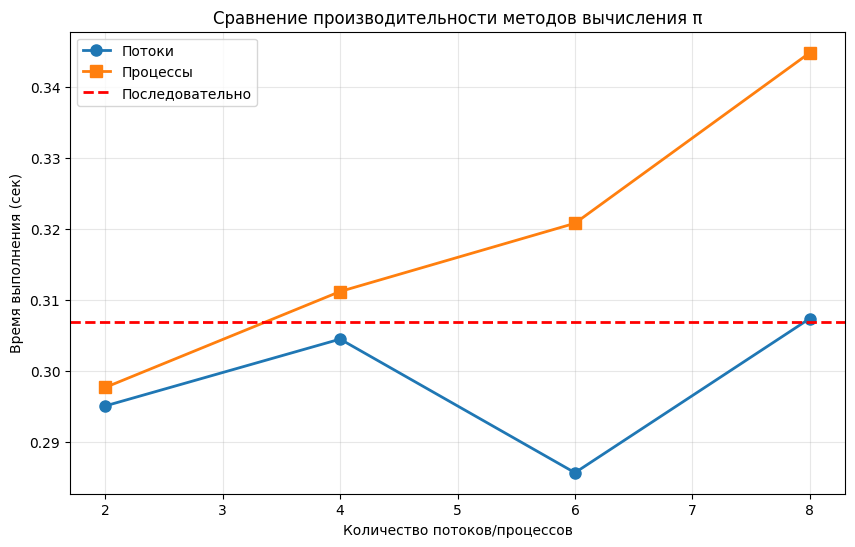

In [9]:
import matplotlib.pyplot as plt

# Данные для визуализации
n_jobs = [2, 4, 6, 8]
threads_times = [0.2951, 0.3045, 0.2857, 0.3074]
processes_times = [0.2977, 0.3112, 0.3208, 0.3448]

plt.figure(figsize=(10, 6))
plt.plot(n_jobs, threads_times, 'o-', label='Потоки', linewidth=2, markersize=8)
plt.plot(n_jobs, processes_times, 's-', label='Процессы', linewidth=2, markersize=8)
plt.axhline(y=0.3069, color='red', linestyle='--', label='Последовательно', linewidth=2)
plt.xlabel('Количество потоков/процессов')
plt.ylabel('Время выполнения (сек)')
plt.title('Сравнение производительности методов вычисления π')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()